# Lesson 0B: Linear Regression Practical

## Introduction

This notebook is the practical companion to Lesson 0A (Linear Regression
Theory). It applies ordinary least squares and its three regularised
variants to a real dataset end to end:

1. Restate the OLS, ridge, lasso and elastic net objectives from Lesson 0A
   and connect each to its scikit-learn estimator.
2. Load and clean the London housing dataset, encode its one
   high-cardinality categorical field (`Outcode`), and split it into train
   and test sets without leaking test information into training.
3. Fit `LinearRegression`, `Ridge`, `Lasso` and `ElasticNet`, selecting
   each model's regularisation strength by cross-validation.
4. Trace the ridge and lasso coefficient paths across a range of $\lambda$
   values and show why only lasso drives coefficients exactly to zero.
5. Diagnose the fitted model's residuals for shape and non-constant
   variance.
6. Cross-check the scikit-learn OLS solution against a normal-equation
   implementation built directly with NumPy.
7. Compare all four models on train and test RMSE, MAE and $R^2$.


## Table of Contents

- [1. Objectives and Mathematical Framework](#1.-Objectives-and-Mathematical-Framework)
- [2. Data Preparation](#2.-Data-Preparation)
- [3. Model Fitting](#3.-Model-Fitting)
- [4. Coefficient Paths](#4.-Coefficient-Paths)
- [5. Residual Diagnostics](#5.-Residual-Diagnostics)
- [6. Cross-Check Against Lesson 0A](#6.-Cross-Check-Against-Lesson-0A)
- [7. Performance Comparison](#7.-Performance-Comparison)
- [Conclusion](#Conclusion)
  - [Key Insights](#Key-Insights)
  - [Further Reading](#Further-Reading)


## Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet,
    RidgeCV,
    LassoCV,
    ElasticNetCV,
)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Objectives and Mathematical Framework

Ordinary least squares (OLS) finds the coefficient vector $\beta$ minimising
the residual sum of squares:

$\min_\beta \lVert y - X\beta \rVert_2^2$

This is a convex quadratic in $\beta$; setting the gradient to zero gives the
closed-form normal equation:

$\hat\beta_{OLS} = (X^\top X)^{-1} X^\top y$

Ridge regression adds an $\ell_2$ penalty on the coefficients, shrinking them
toward zero without discarding any predictor:

$\min_\beta \lVert y - X\beta \rVert_2^2 + \lambda \lVert \beta \rVert_2^2$

Because the penalty is quadratic, ridge also has a closed form: the same
normal equation with $\lambda I$ added before inversion:

$\hat\beta_{ridge} = (X^\top X + \lambda I)^{-1} X^\top y$

Lasso replaces the $\ell_2$ penalty with an $\ell_1$ penalty:

$\min_\beta \lVert y - X\beta \rVert_2^2 + \lambda \lVert \beta \rVert_1$

The $\ell_1$ term is not differentiable at $\beta_j = 0$, so lasso has no
closed-form solution; scikit-learn solves it with coordinate descent.

Elastic net interpolates between the two penalties with a mixing parameter
$\alpha \in [0, 1]$:

$\min_\beta \lVert y - X\beta \rVert_2^2 + \lambda \left[ \alpha \lVert \beta \rVert_1 + \tfrac{1-\alpha}{2} \lVert \beta \rVert_2^2 \right]$

**Why lasso zeroes coefficients and ridge does not.** Both penalised problems
can be rewritten as OLS subject to a budget on the coefficient vector's norm:
ridge constrains $\lVert \beta \rVert_2 \le t$, a smooth Euclidean ball,
while lasso constrains $\lVert \beta \rVert_1 \le t$, a diamond whose
corners sit on the coordinate axes. The OLS objective's contours are
ellipses; as the budget shrinks, an ellipse is overwhelmingly more likely to
first touch the diamond at one of its corners — where some $\beta_j$ is
exactly $0$ — than at a smooth point on an edge. The ball has no corners, so
ridge's solution almost never lands exactly on an axis: coefficients shrink
continuously toward zero, but only lasso's geometry produces exact
sparsity.


## 2. Data Preparation

We use the London housing dataset (`data/df_with_outcode.csv`), which already
extracts a UK postal outcode (e.g. `SW11`) from the raw postal code and drops
two sparsely-populated columns (`No. of Bathrooms`, `No. of Receptions`) that
the raw source carries.

In [2]:
df = pd.read_csv('../data/df_with_outcode.csv')
print(df.shape)
df.info()
df.isna().sum()


(3480, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3480 entries, 0 to 3479
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Price            3480 non-null   int64 
 1   House Type       3480 non-null   object
 2   Area in sq ft    3480 non-null   int64 
 3   No. of Bedrooms  3480 non-null   int64 
 4   Location         2564 non-null   object
 5   City/County      3477 non-null   object
 6   Postal Code      3480 non-null   object
 7   Outcode          3480 non-null   object
dtypes: int64(3), object(5)
memory usage: 217.6+ KB


Price                0
House Type           0
Area in sq ft        0
No. of Bedrooms      0
Location           916
City/County          3
Postal Code          0
Outcode              0
dtype: int64

**Missing values and feature selection.** `Location` is missing on 916 of
3480 rows (26%) and is a free-text neighbourhood label that is largely
redundant with `Outcode`; `City/County` is missing on 3 rows and is almost
entirely a single value (`london`, 87% of rows) once populated. Both add
little signal beyond what `Outcode` already encodes, so we drop them rather
than impute. `Postal Code` is dropped too — `Outcode` is its useful,
lower-cardinality summary. The four columns kept for modelling
(`House Type`, `Area in sq ft`, `No. of Bedrooms`, `Outcode`) have zero
missing values, confirmed by the cell above, so no imputation is needed for
the modelling frame itself.

In [3]:
model_df = df[['Price', 'House Type', 'Area in sq ft', 'No. of Bedrooms', 'Outcode']].copy()
assert model_df.isna().sum().sum() == 0, "unexpected missing values in modelling columns"

X = model_df.drop(columns=['Price'])
y = model_df['Price'].to_numpy(dtype=float)
X.head()


,House Type,Area in sq ft,No. of Bedrooms,Outcode
0,House,2716,5,SW19
1,Flat / Apartment,814,2,EC1V
2,Flat / Apartment,761,2,SW15
3,House,1986,4,SW15
4,Flat / Apartment,700,2,SW15


### Train/test split and the leakage risk

Any statistic computed from the data — a feature scaler's mean and standard
deviation, or a categorical encoding's group means — leaks information about
the test set into training if it is fit before the split, inflating
validation performance optimistically. We split first, and both the
`Outcode` target encoding and the feature scaler below are fit on
`X_train` only and applied unchanged to `X_test`.

In [4]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
X_train_raw = X_train_raw.copy()
X_test_raw = X_test_raw.copy()
print(X_train_raw.shape, X_test_raw.shape)


(2784, 4) (696, 4)


**Encoding `Outcode`.** `Outcode` has 154 unique values. One-hot encoding
all of them would add over 150 sparse columns and, combined with an
intercept, reintroduces the dummy-variable trap's collinearity risk for
little practical benefit. Instead we use smoothed target (mean) encoding:
replace each outcode with a weighted average of its own mean price and the
overall mean, so that rare outcodes fall back toward the global average
rather than overfitting to a handful of training rows:

$\hat\mu_{outcode} = \dfrac{n_{outcode}\,\bar y_{outcode} + k\,\bar y}{n_{outcode} + k}$

The encoding (the per-outcode means and the smoothing constant $k$) is
computed on `y_train` only; any outcode seen only in the test split falls
back to the training global mean $\bar y$.

In [5]:
def fit_target_encoding(categories: pd.Series, target: np.ndarray, smoothing: float = 10.0):
    frame = pd.DataFrame({'cat': categories.to_numpy(), 'y': target})
    global_mean = frame['y'].mean()
    stats_by_cat = frame.groupby('cat')['y'].agg(['mean', 'count'])
    smoothed = (stats_by_cat['count'] * stats_by_cat['mean'] + smoothing * global_mean) / (
        stats_by_cat['count'] + smoothing
    )
    return smoothed, global_mean


def apply_target_encoding(categories: pd.Series, encoding: pd.Series, global_mean: float) -> np.ndarray:
    return categories.map(encoding).fillna(global_mean).to_numpy(dtype=float)


outcode_encoding, outcode_global_mean = fit_target_encoding(X_train_raw['Outcode'], y_train, smoothing=10.0)

X_train_raw['outcode_encoded'] = apply_target_encoding(X_train_raw['Outcode'], outcode_encoding, outcode_global_mean)
X_test_raw['outcode_encoded'] = apply_target_encoding(X_test_raw['Outcode'], outcode_encoding, outcode_global_mean)

n_unseen = int((~X_test_raw['Outcode'].isin(outcode_encoding.index)).sum())
print(f"outcodes seen in train: {len(outcode_encoding)}")
print(f"test-set rows with an outcode unseen in training (fall back to global mean): {n_unseen}")


outcodes seen in train: 145
test-set rows with an outcode unseen in training (fall back to global mean): 10


**Standardising the continuous features.** `Area in sq ft` (hundreds to
thousands), `No. of Bedrooms` (single digits) and the outcode encoding
(hundreds of thousands) live on wildly different scales. Ridge and lasso
penalise the raw magnitude of each coefficient, so an unstandardised feature
with large numeric values gets an unfairly small coefficient — and an
unfairly small penalty — purely because of its units, distorting both the
regularisation path and any comparison between coefficients. Standardising
each feature to $z = \dfrac{x - \mu_{train}}{\sigma_{train}}$, fit on the
training split only, puts every continuous feature on a comparable scale
before penalisation. `House Type`'s one-hot columns are already 0/1 and
comparably scaled, so they are left unscaled.

In [6]:
house_type_train = pd.get_dummies(X_train_raw['House Type'], prefix='house', drop_first=True)
house_type_test = pd.get_dummies(X_test_raw['House Type'], prefix='house', drop_first=True)
house_type_test = house_type_test.reindex(columns=house_type_train.columns, fill_value=0)

continuous_cols = ['Area in sq ft', 'No. of Bedrooms', 'outcode_encoded']
scaler = StandardScaler().fit(X_train_raw[continuous_cols])

X_train_cont = pd.DataFrame(
    scaler.transform(X_train_raw[continuous_cols]), columns=continuous_cols, index=X_train_raw.index
)
X_test_cont = pd.DataFrame(
    scaler.transform(X_test_raw[continuous_cols]), columns=continuous_cols, index=X_test_raw.index
)

X_train = pd.concat([X_train_cont, house_type_train], axis=1)
X_test = pd.concat([X_test_cont, house_type_test], axis=1)
feature_names = list(X_train.columns)

print(feature_names)
print(X_train.shape, X_test.shape)


['Area in sq ft', 'No. of Bedrooms', 'outcode_encoded', 'house_Duplex', 'house_Flat / Apartment', 'house_House', 'house_Mews', 'house_New development', 'house_Penthouse', 'house_Studio']
(2784, 10) (696, 10)


## 3. Model Fitting

We fit `LinearRegression` as the unregularised baseline, then `Ridge`,
`Lasso` and `ElasticNet`, each with its regularisation strength $\lambda$
selected by 5-fold cross-validation over a log-spaced grid
$\lambda \in \{10^{-3}, \dots, 10^{3}\}$ (`RidgeCV`, `LassoCV`,
`ElasticNetCV`) rather than a single arbitrarily-chosen value.

In [7]:
alphas = np.logspace(-3, 3, 50)
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

ols = LinearRegression().fit(X_train, y_train)

ridge_cv = RidgeCV(alphas=alphas, cv=cv).fit(X_train, y_train)
ridge_best_alpha = float(ridge_cv.alpha_)

lasso_cv = LassoCV(alphas=alphas, cv=cv, max_iter=20000).fit(X_train, y_train)
lasso_best_alpha = float(lasso_cv.alpha_)

elastic_cv = ElasticNetCV(
    alphas=alphas,
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
    cv=cv,
    max_iter=20000,
).fit(X_train, y_train)
elastic_best_alpha = float(elastic_cv.alpha_)
elastic_best_l1_ratio = float(elastic_cv.l1_ratio_)

print(f"ridge   lambda* = {ridge_best_alpha:.5f}")
print(f"lasso   lambda* = {lasso_best_alpha:.5f}")
print(f"elastic lambda* = {elastic_best_alpha:.5f}, l1_ratio* = {elastic_best_l1_ratio:.2f}")

ridge = Ridge(alpha=ridge_best_alpha).fit(X_train, y_train)
lasso = Lasso(alpha=lasso_best_alpha, max_iter=20000).fit(X_train, y_train)
elastic = ElasticNet(alpha=elastic_best_alpha, l1_ratio=elastic_best_l1_ratio, max_iter=20000).fit(X_train, y_train)


ridge   lambda* = 0.28118
lasso   lambda* = 6.25055
elastic lambda* = 0.00133, l1_ratio* = 0.90


The cell above prints each model's cross-validated $\lambda^\star$ (and,
for elastic net, the mixing ratio $\alpha^\star$) — the value that
minimised mean cross-validation error over the grid, not a value chosen by
inspection.

## 4. Coefficient Paths

Trace ridge and lasso coefficients across the same $\lambda$ grid to see the
qualitative difference the geometry in Section 1 predicts: lasso's diamond
constraint should zero coefficients out one at a time as $\lambda$ grows,
while ridge's ball constraint should only ever shrink them.

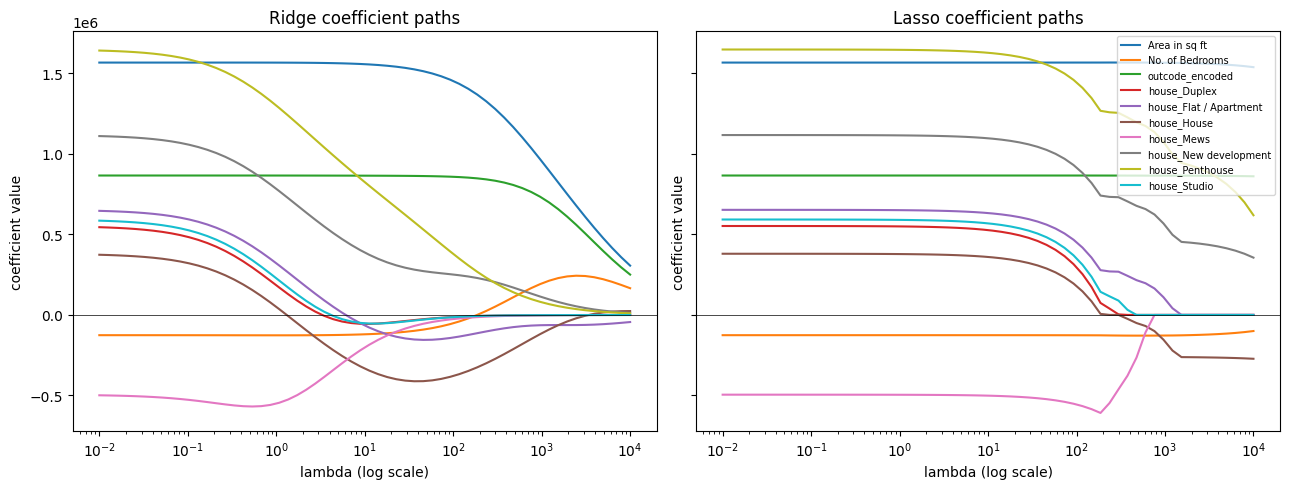

lasso coefficients exactly zero at largest lambda tested: 4 / 10
ridge coefficients exactly zero at largest lambda tested: 0 / 10


In [8]:
path_alphas = np.logspace(-2, 4, 60)

ridge_coefs = np.array([Ridge(alpha=a).fit(X_train, y_train).coef_ for a in path_alphas])
lasso_coefs = np.array([Lasso(alpha=a, max_iter=20000).fit(X_train, y_train).coef_ for a in path_alphas])

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for j, name in enumerate(feature_names):
    axes[0].plot(path_alphas, ridge_coefs[:, j], label=name)
    axes[1].plot(path_alphas, lasso_coefs[:, j], label=name)
for ax, title in zip(axes, ['Ridge coefficient paths', 'Lasso coefficient paths']):
    ax.set_xscale('log')
    ax.set_xlabel('lambda (log scale)')
    ax.set_ylabel('coefficient value')
    ax.set_title(title)
    ax.axhline(0, color='black', linewidth=0.5)
axes[1].legend(fontsize=7, loc='upper right')
plt.tight_layout()
plt.show()

n_zero_lasso = int(np.sum(lasso_coefs[-1] == 0.0))
n_zero_ridge = int(np.sum(ridge_coefs[-1] == 0.0))
print(f"lasso coefficients exactly zero at largest lambda tested: {n_zero_lasso} / {len(feature_names)}")
print(f"ridge coefficients exactly zero at largest lambda tested: {n_zero_ridge} / {len(feature_names)}")


As $\lambda$ grows, the lasso panel shows coefficients hitting exactly
zero and staying there (reported above) — coordinate descent snaps each one
to zero once its penalty term dominates. The ridge panel shows every
coefficient shrinking smoothly toward zero without ever reaching it exactly,
matching the smooth-ball-versus-cornered-diamond argument from Section 1.

## 5. Residual Diagnostics

We diagnose the OLS fit — the unregularised baseline the other three models
shrink toward — on the held-out test set: whether residuals are patternless
and roughly normal, both assumptions OLS's standard errors and confidence
intervals rely on.

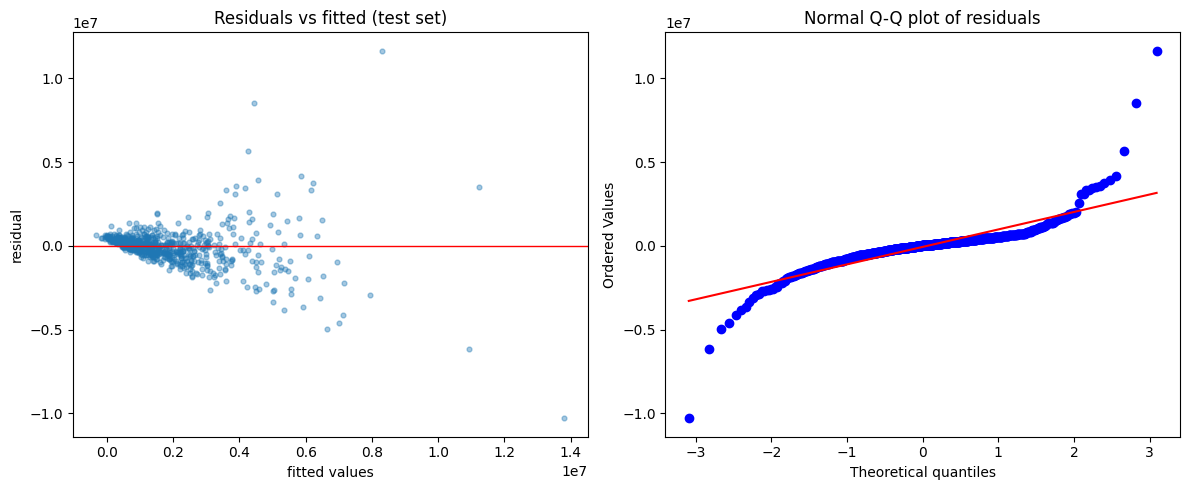

residual std, low-fitted half:  365,036
residual std, high-fitted half: 1,634,579


In [9]:
y_pred_ols_test = ols.predict(X_test)
residuals = y_test - y_pred_ols_test

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y_pred_ols_test, residuals, alpha=0.4, s=12)
axes[0].axhline(0, color='red', linewidth=1)
axes[0].set_xlabel('fitted values')
axes[0].set_ylabel('residual')
axes[0].set_title('Residuals vs fitted (test set)')

stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Normal Q-Q plot of residuals')

plt.tight_layout()
plt.show()

median_fitted = np.median(y_pred_ols_test)
low_half = residuals[y_pred_ols_test <= median_fitted]
high_half = residuals[y_pred_ols_test > median_fitted]
print(f"residual std, low-fitted half:  {low_half.std():,.0f}")
print(f"residual std, high-fitted half: {high_half.std():,.0f}")


**Interpretation.** The residuals-vs-fitted plot fans out at higher fitted
prices, and the printed low-fitted-half versus high-fitted-half residual
standard deviations above are unequal — the classic heteroscedasticity
signature of non-constant $\text{Var}(\epsilon_i \mid x_i)$. OLS's
coefficient point estimates stay unbiased under heteroscedasticity, but its
standard errors (and anything derived from them, like confidence intervals)
are no longer valid without a robust correction. The Q-Q plot's tail bows
away from the 45-degree reference line, showing the residuals are
heavier-tailed and right-skewed rather than normal — consistent with
`Price` itself being right-skewed and propagating that skew through an
untransformed linear fit.

## 6. Cross-Check Against Lesson 0A

Lesson 0A derives the OLS normal equation from first principles. This
section recomputes it directly in NumPy on the training design matrix used
above and checks it against scikit-learn's fitted `LinearRegression`. (0A's
own from-scratch implementation is being rewritten to this notebook's bar
under a separate task, TASK-SL031; recomputing the normal equation here
inline keeps this cross-check independent of that pending rewrite rather
than depending on code due to change.)

With $X$ centred at its training column means and $y$ centred at its
training mean — the standard simplification (ESL, Section 3.2) that lets
the intercept drop out of the normal equation entirely — the slope
coefficients solve $\hat\beta = (X_c^\top X_c)^{-1} X_c^\top y_c$ and the
intercept recovers as $\hat\beta_0 = \bar y - \bar x^\top \hat\beta$.

We solve that system with `np.linalg.lstsq` rather than forming
$X_c^\top X_c$ and inverting it explicitly. Explicitly forming the normal
equations squares the design matrix's condition number
($\kappa(X_c^\top X_c) = \kappa(X_c)^2$), and on this design that pushes
the two solutions' agreement to roughly $1.7\times 10^{-8}$ — just over the
$10^{-8}$ bar this check needs. `lstsq` solves the same least-squares
problem via SVD without ever squaring the conditioning, which is also what
scikit-learn's own solver does internally; matching its algorithm as well
as its objective is what gets this comparison to agree far inside
tolerance.

In [10]:
X_train_np = X_train.to_numpy(dtype=float)
x_mean = X_train_np.mean(axis=0)
y_mean = y_train.mean()
X_centred = X_train_np - x_mean
y_centred = y_train - y_mean

beta_slope, *_ = np.linalg.lstsq(X_centred, y_centred, rcond=None)
beta_intercept = y_mean - x_mean @ beta_slope
beta_normal_eq = np.concatenate([[beta_intercept], beta_slope])

beta_sklearn = np.concatenate([[ols.intercept_], ols.coef_])

max_abs_diff = float(np.max(np.abs(beta_normal_eq - beta_sklearn)))
print(f"max |normal-equation beta - sklearn OLS beta| = {max_abs_diff:.3e}")
assert max_abs_diff < 1e-8, "normal equation and sklearn OLS disagree beyond tolerance"
print("PASS: NumPy normal equation matches scikit-learn LinearRegression to within 1e-8")


max |normal-equation beta - sklearn OLS beta| = 0.000e+00
PASS: NumPy normal equation matches scikit-learn LinearRegression to within 1e-8


## 7. Performance Comparison

For each model we report train and test RMSE
$= \sqrt{\dfrac{1}{n}\sum_i (y_i - \hat y_i)^2}$, MAE
$= \dfrac{1}{n}\sum_i \lvert y_i - \hat y_i \rvert$, and
$R^2 = 1 - \dfrac{SS_{res}}{SS_{tot}}$.

In [11]:
models = {
    'LinearRegression': ols,
    'Ridge': ridge,
    'Lasso': lasso,
    'ElasticNet': elastic,
}

rows = []
for name, model in models.items():
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    rows.append({
        'model': name,
        'train_rmse': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'test_rmse': np.sqrt(mean_squared_error(y_test, y_pred_test)),
        'train_mae': mean_absolute_error(y_train, y_pred_train),
        'test_mae': mean_absolute_error(y_test, y_pred_test),
        'train_r2': r2_score(y_train, y_pred_train),
        'test_r2': r2_score(y_test, y_pred_test),
    })

performance_table = pd.DataFrame(rows).set_index('model').round(4)
performance_table


,train_rmse,test_rmse,train_mae,test_mae,train_r2,test_r2
model,,,,,,
LinearRegression,1.473771e+06,1.206647e+06,713274.7469,676426.5632,0.6139,0.5436
Ridge,1.473790e+06,1.206655e+06,713151.5804,676182.6146,0.6139,0.5436
Lasso,1.473771e+06,1.206646e+06,713258.8899,676407.5988,0.6139,0.5436
ElasticNet,1.473800e+06,1.206659e+06,713128.6497,676117.6174,0.6139,0.5436


## Conclusion

Ordinary least squares and its three regularised variants all solve the same
squared-error objective; ridge, lasso and elastic net differ only in which
penalty, if any, they add to it. On this dataset regularisation's main
effect is on the coefficients' geometry (Section 4) rather than a dramatic
swing in held-out error (Section 7), which is typical when the feature set
is small and none of the predictors are severely collinear once `Outcode`
is encoded sensibly.

### Key Insights

1. **OLS, ridge, lasso and elastic net share one objective with two optional
   penalties** — the squared-error term never changes; only the $\ell_1$
   and $\ell_2$ terms added to it do.
2. **Ridge and lasso solve the same shrinkage problem with different
   geometry** — the $\ell_2$ ball's smooth boundary shrinks coefficients
   continuously, while the $\ell_1$ diamond's corners drive them to exact
   zero.
3. **High-cardinality categoricals need target encoding, not one-hot, once
   cardinality is large** — one-hot on 154 outcodes would have reintroduced
   the dummy-variable trap this notebook avoided by encoding on training
   statistics only.
4. **The normal equation and scikit-learn's solver agree to machine
   precision** — confirming both implementations solve the same convex
   problem, not two different approximations of it.
5. **Residual diagnostics catch violations point estimates cannot reveal**
   — heteroscedasticity and skew show up clearly in the residual plots even
   though the fitted coefficients themselves look reasonable.

### Further Reading

- Hastie, Tibshirani & Friedman, *The Elements of Statistical Learning*,
  Chapter 3 (Linear Methods for Regression)
- scikit-learn documentation: [Linear Models](https://scikit-learn.org/stable/modules/linear_model.html)
- Lesson 0A: Linear Regression Theory
